# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Chrishelle Yaa Agyeiwaa Wiafe
**Student ID:** 85942028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [13]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

[np.float64(1.950677294037857), np.float64(1.7858943722796556), np.float64(1.6388298913316675), np.float64(1.507453841306312), np.float64(1.389974246866815), np.float64(1.284809032035519), np.float64(1.1905612194925288), np.float64(1.105997068815263), np.float64(1.0300268050451316), np.float64(0.961687630333329), np.float64(0.9001287478745393), np.float64(0.8445981594678658), np.float64(0.7944310263618665), np.float64(0.7490394079977526), np.float64(0.7079032152603487), np.float64(0.6705622342318099), np.float64(0.6366090935280877), np.float64(0.6056830633557404), np.float64(0.5774645876974795), np.float64(0.5516704627308888), np.float64(0.5280495848929244), np.float64(0.5063792010877978), np.float64(0.4864616015428174), np.float64(0.4681212028736706), np.float64(0.45120197514015964), np.float64(0.435565172155001), np.float64(0.4210873291394702), np.float64(0.40765849607763793), np.float64(0.395180678873721), np.float64(0.38356646372459374), np.float64(0.372737803034626), np.float64(0.

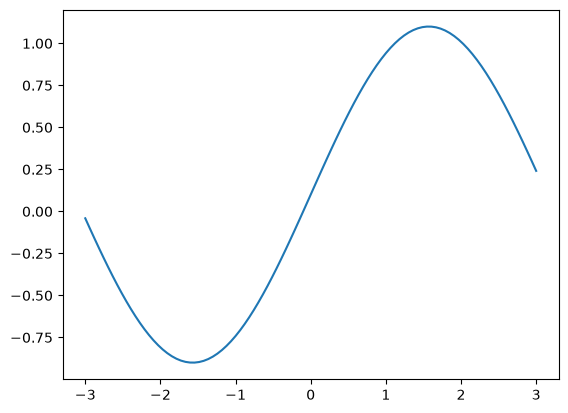

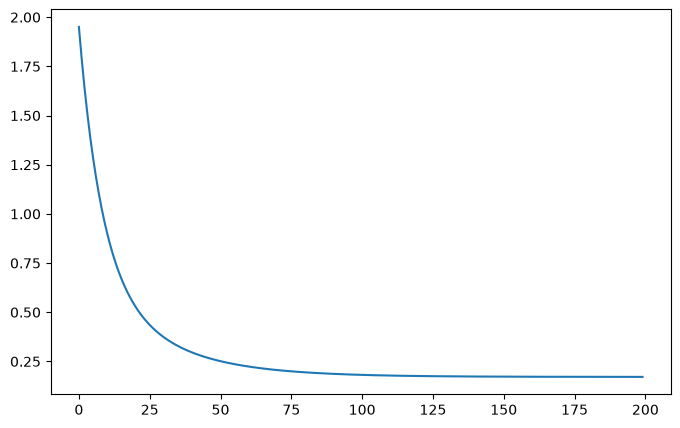

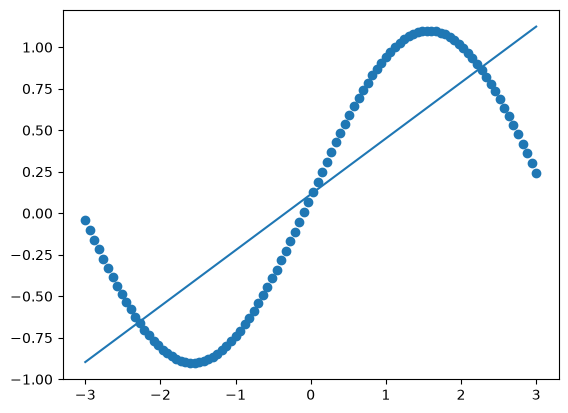

In [14]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
import random

x = np.linspace(-3 ,3, 100)
std=0.1
y = np.sin(x) + std
plt.plot(x, y)

# TODO: Initialise w and b to small random values.
w=random.random()
b=random.random()
lr = 0.01


# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

s=200
loss_a=[]
for i in range(0,s):
    y_hat = w* x + b
    loss = np.mean((y_hat - y) ** 2)
    loss_a.append(loss)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db


print(loss_a)



# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

plt.figure(figsize=(8,5))
plt.plot(range(0,200),loss_a)

plt.figure()
plt.scatter(x,y)
plt.plot(x, y_hat)





**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** 
1. It matches the code{picture attached as file}
2. This is a clear case of underfitting, because we see in the graph that the loss curve flattens into a straight line, which is a sign of a bad fit.
A single neuron can never fit a sine wave because it would in every case equate to a straight line. No matter how long you train it, it would always be a straight line because there is no change along x to produce curves in the function's slope

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

Text(0.5, 1.0, 'Training Loss')

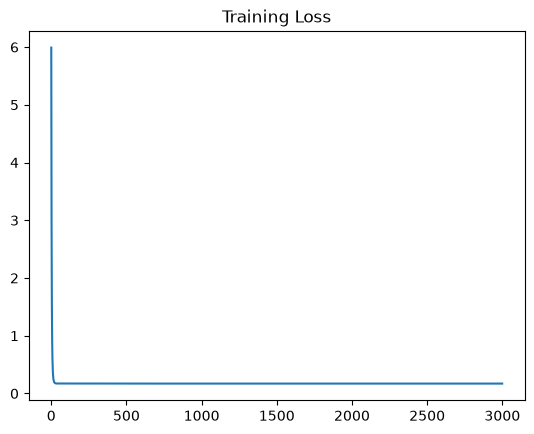

In [15]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

W1=(np.random.randn(1,8) * 0.5)
W2=(np.random.randn(8,1) * 0.5)
b1=(np.random.randn(8,) * 0.5)
b2=(np.random.randn(1,) * 0.5)

x = x.reshape(-1,1)
y = y.reshape(-1,1)
# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)
losses=[]

for i in range(3000):
    z1 = x @ W1 + b1
    h = z1
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2




# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure()
plt.plot(losses)
plt.title("Training Loss")



**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** 1. When tanh is removed, the stack of linear layers collapses into one linear layer because all the layers perform only a linear transformation, reducing the ability of the model to fit the data. The previous equation was                     h = tanh(z1)
                                            = tanh(xW1 + b1)
Without it, the network becomes;          y_hat=(xW1 + b1)W2 + b2
                                          y_hat=x(W1W2) + (b1W2 + b2)
                                this equates to y=mx +b; which is the equation of a straight line
                                        
2. The hidden layer's 8 neuron, after the tanh was applied, each learned a different nonlinear transformation of the input. This allowed the network to produce various parts and patterns of the function, allowing it enough flexibility to accommodate the nonlinear data
3. Backpropagation is the core algorithm that calculates how much each weight and bias in the network combine to produce an error, allowing gradient descent to update parameters effectively

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

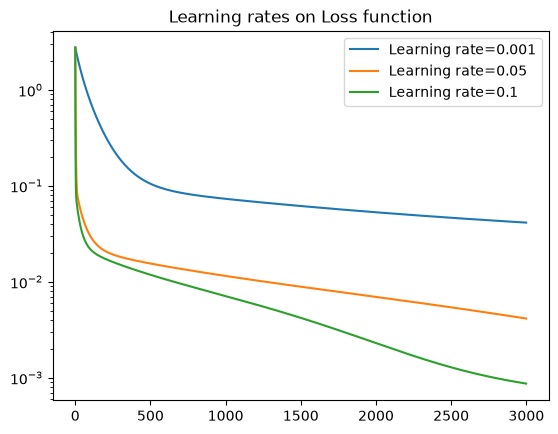

In [16]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

def train_func(lr,steps=3000):
    np.random.seed(42)

    W1=(np.random.randn(1,8) * 0.5)
    W2=(np.random.randn(8,1) * 0.5)
    b1=(np.random.randn(8,) * 0.5)
    b2=(np.random.randn(1,) * 0.5)

    losses=[]

    for i in range(3000):
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)


        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses


# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
first_rate = train_func(0.001)
sec_rate = train_func(0.05)
third_rate = train_func(0.1)


# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
# plt.figure()

plt.plot(first_rate, label="Learning rate=0.001")
plt.plot(sec_rate, label="Learning rate=0.05")
plt.plot(third_rate, label="Learning rate=0.1")

plt.yscale("log")
plt.title("Learning rates on Loss function")
plt.legend()
plt.show()






**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** The three curves show the different learning rates and how each influences the gradient descent. With the lr of o.oo1, because the value is small, the loss decreases slowly. With the lr of 0.5, this value is moderate enough to provide a good balance to how the loss updates. An increase to 0.1, makes the model speed up in learning which results in a less stable training, causing it to overshoot the weights and the biases. 
If the learning rate is too large, the optimizer jumps so large that it moves the weights into regions where the loss is higher, so instead of converging, it repeatedly overshoots the minimum causing it to oscillate

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "Obesity-Level-Prediction-Dataset.csv"

obesity = pd.read_csv(OBESITY_URL)

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
bin_col = ['family_history_with_overweight','FAVC','SMOKE','SCC']
#['Gender','MTRANS','CAEC','CALC']
for c in bin_col:
    obesity[c]=obesity[c].map({'yes':1,'no':0})

ordinalish_col=['CAEC','CALC']
for oc in ordinalish_col:
    obesity[oc]=obesity[oc].map({'no':0,'Sometimes':1,'Frequently':2,'Always':3})

obesity['BMI']=obesity['Weight']/(obesity['Height']**2)
obesity=pd.get_dummies(obesity,columns=['Gender','MTRANS'],drop_first=True, dtype=int)

#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
label_encoder = LabelEncoder()
obesity['NObeyesdad'] = label_encoder.fit_transform(obesity['NObeyesdad'])
# y = label_encoder.fit_transform(obesity["NObeyesdad"])


# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
# a = obesity.drop(columns=['NObeyesdad'])
# z = y

a = obesity.drop(columns=['NObeyesdad']) # Representing every column except the target
z = obesity['NObeyesdad']

a_train, a_test, z_train, z_test = train_test_split(
    a, z, test_size=0.20, stratify=z, random_state=RANDOM_STATE, shuffle=True
)
a_train, a_val, z_train, z_val = train_test_split(
    a_train, z_train, test_size=0.25, stratify=z_train, random_state=RANDOM_STATE, shuffle=True
)



# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)
scaler=StandardScaler()



num_col=['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE','BMI']
 
a_train[num_col]=scaler.fit_transform(a_train[num_col])

a_val[num_col]=scaler.transform(a_val[num_col])
a_test[num_col]=scaler.transform(a_test[num_col])

# print(a_train.values.dtype)

bool_cols = a_train.select_dtypes(include='bool').columns

a_train[bool_cols] = a_train[bool_cols].astype(np.float32)
a_val[bool_cols] = a_val[bool_cols].astype(np.float32)
a_test[bool_cols] = a_test[bool_cols].astype(np.float32)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
# a_train_t = torch.tensor(a_train.values, dtype=torch.float32)
# a_val_t = torch.tensor(a_val.values,dtype=torch.float32)
# a_test_t = torch.tensor(a_test.values,dtype=torch.float32)

# z_train_t = torch.tensor(z_train,dtype=torch.long)
# z_val_t = torch.tensor(z_val,dtype=torch.long)
# z_test_t = torch.tensor(z_test,dtype=torch.long)

a_train_t = torch.tensor(a_train.values, dtype=torch.float32)
z_train_t = torch.tensor(z_train.values, dtype=torch.long)

a_val_t = torch.tensor(a_val.values, dtype=torch.float32)
z_val_t = torch.tensor(z_val.values, dtype=torch.long)

a_test_t = torch.tensor(a_test.values, dtype=torch.float32)
z_test_t = torch.tensor(z_test.values, dtype=torch.long)

train_dtset = TensorDataset(a_train_t,z_train_t)
val_dtset = TensorDataset(a_val_t,z_val_t)
test_dtset = TensorDataset(a_test_t,z_test_t)

train_loader = DataLoader(train_dtset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dtset,batch_size=32,shuffle=False)
test_loader = DataLoader(test_dtset,batch_size=32,shuffle=False)

print(len(train_dtset), len(val_dtset), len(test_dtset))



1266 422 423


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 
1. CrossEntropyLoss needs integer class labels rather than one-hot vectors because it uses these integer values when calulating losses. Making use of integers also uses less memory than one-hot vectors
2. Neural networks care about feature scaling because their weights are upgraded using gradient functions, and these gradients also depend on the inputs. If there is a case where some features are way larger than others, it becomes uneven, making the model learn slowly. So scaling ensures a faster and smoother learning
3. 'shuffle=True' ensures the model learns the actual patterns of the data instead of its order. This also helps the model to learn better and improve upon its performance

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [18]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim,hidden_sizes=(64,32),n_classes=7,dropout=0.0):
        super().__init__()
        dims = [input_dim, *hidden_sizes, n_classes]
        layers=[]

        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i],dims[i+1]))
            if i != len(dims) - 2:
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))

        self.net = nn.Sequential(*layers)

       
    def forward(self,x):
        return self.net(x)
# TODO: Instantiate, move to DEVICE, print the model.

input_dim = a_train.shape[1]

model = FeedForwardNet(input_dim=a_train_t.shape[1])
print(model.to(DEVICE))

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
par_num = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(par_num)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
3655


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** 
1. The first layer has weights equal to input_dim x 64, and the biases are 64 as well. Total(first hidden layer) = 20 x 64 + 64
               = 1280 + 64
               = 1344
The second layer has inputs of 64 and biases of 32
         Total(second hidden layer) = 64 x 32 + 32
               = 2080
The last(output) layer has inputs 32 and 7 biases(classes)
          Total(output layer) = 32 x 7 + 7
                = 231

        Total = 1344 + 2048 + 231
                = 3655
    This matches the PyTorch output

2. ReLu is used instead of tanh because it trains the neural networks faster, and it also removes the risk of the early layers barely learning with the gradual reduction in gradients(with the use of tan). An advantage is learning becomes more efficient, even as the number of layers increase

3. If the ReLu activation was removed, all the layers would collapse into one linear transformation and the entire netwrok would behave like a single layer. This prevents the model from learning any complex or non-linear patterns

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 1/50 | Train Loss: 1.8143 | Train Acc: 0.3712 | Val Loss: 1.8150 | Val Acc: 0.3318
Epoch 2/50 | Train Loss: 1.4390 | Train Acc: 0.5924 | Val Loss: 1.4391 | Val Acc: 0.5711
Epoch 3/50 | Train Loss: 1.0093 | Train Acc: 0.6698 | Val Loss: 1.0150 | Val Acc: 0.6659
Epoch 4/50 | Train Loss: 0.7652 | Train Acc: 0.7686 | Val Loss: 0.7738 | Val Acc: 0.7773
Epoch 5/50 | Train Loss: 0.5980 | Train Acc: 0.8547 | Val Loss: 0.6085 | Val Acc: 0.8436
Epoch 6/50 | Train Loss: 0.4895 | Train Acc: 0.8799 | Val Loss: 0.5007 | Val Acc: 0.8507
Epoch 7/50 | Train Loss: 0.3996 | Train Acc: 0.8997 | Val Loss: 0.4198 | Val Acc: 0.8626
Epoch 8/50 | Train Loss: 0.3385 | Train Acc: 0.9163 | Val Loss: 0.3656 | Val Acc: 0.8815
Epoch 9/50 | Train Loss: 0.2932 | Train Acc: 0.9321 | Val Loss: 0.3257 | Val Acc: 0.9028
Epoch 10/50 | Train Loss: 0.2793 | Train Acc: 0.9147 | Val Loss: 0.3199 | Val Acc: 0.8910
Epoch 11/50 | Train Loss: 0.2299 | Train Acc: 0.9400 | Val Loss: 0.2725 | Val Acc: 0.9194
Epoch 12/50 | Train

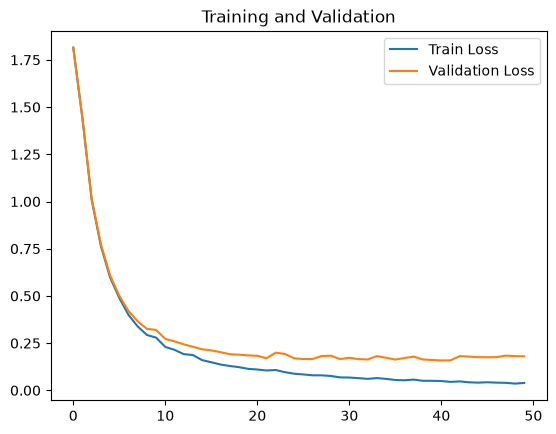

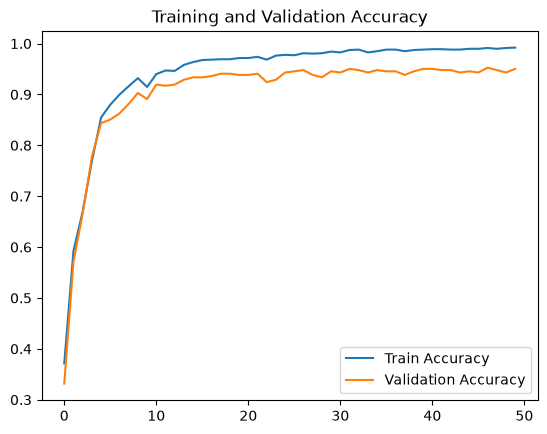

In [19]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  


# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.


def evaluate(loader):
    model.eval()
        
    n = 0
    corr = 0
    total = 0
        
    with torch.no_grad():
        for xb, yb in loader:
            xb,yb =xb.to(DEVICE),yb.to(DEVICE)
            logits = model(xb)
        
            loss = criterion(logits, yb)
        
            total += loss.item() * len(yb)
        
            pred = logits.argmax(dim=1)
                    
            corr += (pred == yb).sum().item()
            n += len(yb)
        
    return total / n, corr / n


model.train()
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


for epoch in range(0, 50):
    for xb, yb in train_loader:

        optimizer.zero_grad()
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        loss.backward()
        optimizer.step()
        

    train_loss, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)   

    # print(f"training loss: {train_loss}")
    # print(f"training accuracies: {train_acc}")

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    

    print(
        f"Epoch {epoch + 1}/{50} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )  

    
# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
torch.save(model.state_dict(), "ffn_best.pt")



# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation")
plt.legend()

plt.figure()
plt.plot(train_accuracies,label="Train Accuracy")
plt.plot(val_accuracies,label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()


**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** 

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [20]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [21]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** 
1. The loss.backward() function initially calculates the loss gradient of each weight and bias using the backpropagation method. The purpose of these gradients is to inform the model of how each parameter contributed to the prediction error and how it should be modified in order to reduce the loss. The optimizer.step() function acts on these gradients to update the weights and biases so the model is able to make better predictions in the next run.

2. Out of all the hyperparameters, I would tune only the learning rate because it seems to play a large role or have a large effect on the outcome of the model's learning. If the learning rate seems too high, the model may overshoot the minimum and fail to converge. If it is also too low, the training tends to become very slow and may stop working before reaching the solution

3. 

4. A plain MLP treats every input feature independently and so it does not factor in the spatial relationship between two adjacent pixels. Due to this it cannot efficiently recognize patterns like shapes, texture, etc. A better architecture should accommodate teh ability to learn local features or properties as well as preserve the spatial structure of the image 

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.